In [46]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [47]:
df = pd.read_csv('iris.csv')

In [48]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [50]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Filter only those records where flower type is setosa or versicolor. [Y Column should be numeric say 0 or 1]

In [51]:
filtered_df = df[df['Species'].isin(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])].copy()
filtered_df['Species'] = filtered_df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
features = filtered_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
X = features.values
Y = filtered_df['Species'].to_numpy(dtype=np.int64)

## Normalization of X

In [52]:
def normalize(X):
    print("Mean Before: ", X.mean(axis=0), "\nStd dev. Before: ", X.std(axis=0))

    sc = StandardScaler()
    XScaled = sc.fit_transform(X)

    print("Mean After: ",XScaled.mean(axis=0), "\nStd dev. After: ",XScaled.std(axis=0))
    return XScaled

## Train-Test and Split using K-fold cross validation

In [56]:
def decisionTree(X, y, fold_scores):
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=20)
    for train_index, test_index in kf.split(X, y):
        # Split data into train and test sets for the current fold
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        LRModel = tree.DecisionTreeClassifier()
        LRModel.fit(X_train, y_train)
        score = LRModel.score(X_test, y_test)
        fold_scores.append(score)

        Ytest_pred = LRModel.predict(X_test)
        Ytrain_pred = LRModel.predict(X_train)
        print("Predicted labels: ", Ytest_pred)
        print("Training Accuracy: ", accuracy_score(y_train, Ytrain_pred))
        print("Test Accuracy: ", accuracy_score(y_test, Ytest_pred))

        confusion_matrix(y_test, Ytest_pred)
        plot_confusion_matrix(confusion_matrix(y_test, Ytest_pred), figsize=(6, 6), hide_ticks=True, cmap=plt.cm.Blues)
        print(classification_report(y_test, Ytest_pred))
        return fold_scores


## Create a Decison Tree model by training on train partition(X_train, Y_train).

Mean Before:  [5.84333333 3.054      3.75866667 1.19866667] 
Std dev. Before:  [0.82530129 0.43214658 1.75852918 0.76061262]
Mean After:  [-4.73695157e-16 -6.63173220e-16  3.31586610e-16 -2.84217094e-16] 
Std dev. After:  [1. 1. 1. 1.]
Predicted labels:  [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]
Training Accuracy:  1.0
Test Accuracy:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



[1.0]

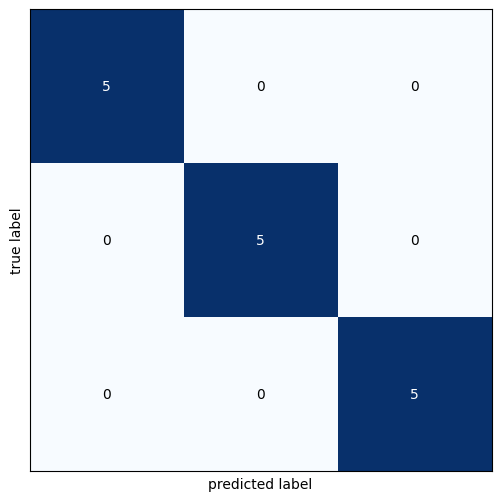

In [57]:
XScaled = normalize(X)
result = decisionTree(XScaled, Y, [])
result

In [55]:
print(type(Y), Y.shape)
print('dtype:', Y.dtype)
print('first 10:', Y[:10])
print('unique:', np.unique(Y))

<class 'numpy.ndarray'> (150,)
dtype: int64
first 10: [0 0 0 0 0 0 0 0 0 0]
unique: [0 1 2]
